# Complaint Dataset EDA and Preprocessing

This notebook performs Exploratory Data Analysis (EDA) and preprocessing on the CFPB complaint dataset for the complaint-answering chatbot project. The tasks include loading the dataset, analyzing complaint distributions, examining narrative lengths, filtering for specific products, cleaning text narratives, and saving the processed dataset.

In [7]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
import nltk
from nltk.tokenize import word_tokenize

# Download NLTK data
nltk.download('punkt')

# Set up paths
DATA_PATH = Path(r'C:\Users\Daniel.Temesgen\Desktop\KIAM-Rsc')
INPUT_FILE = DATA_PATH / 'complaints.csv'
OUTPUT_FILE = DATA_PATH / 'filtered_complaints.csv'

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Daniel.Temesgen\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Load Dataset

Load the CFPB complaint dataset from the `data/` directory. Ensure the dataset file is placed in the correct location.

In [8]:
# Load dataset
try:
    df = pd.read_csv(INPUT_FILE)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Please place the CFPB complaints dataset in the KIAM-Rsc folder on your Desktop.")
    exit(1)

C:\Users\Daniel.Temesgen\AppData\Local\Temp\ipykernel_25820\349190480.py:3: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_FILE)


Dataset loaded successfully.


In [9]:
df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


## Exploratory Data Analysis

Perform EDA to understand the dataset's structure, complaint distribution, and narrative characteristics.

Dataset Shape: (9609797, 18)

Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


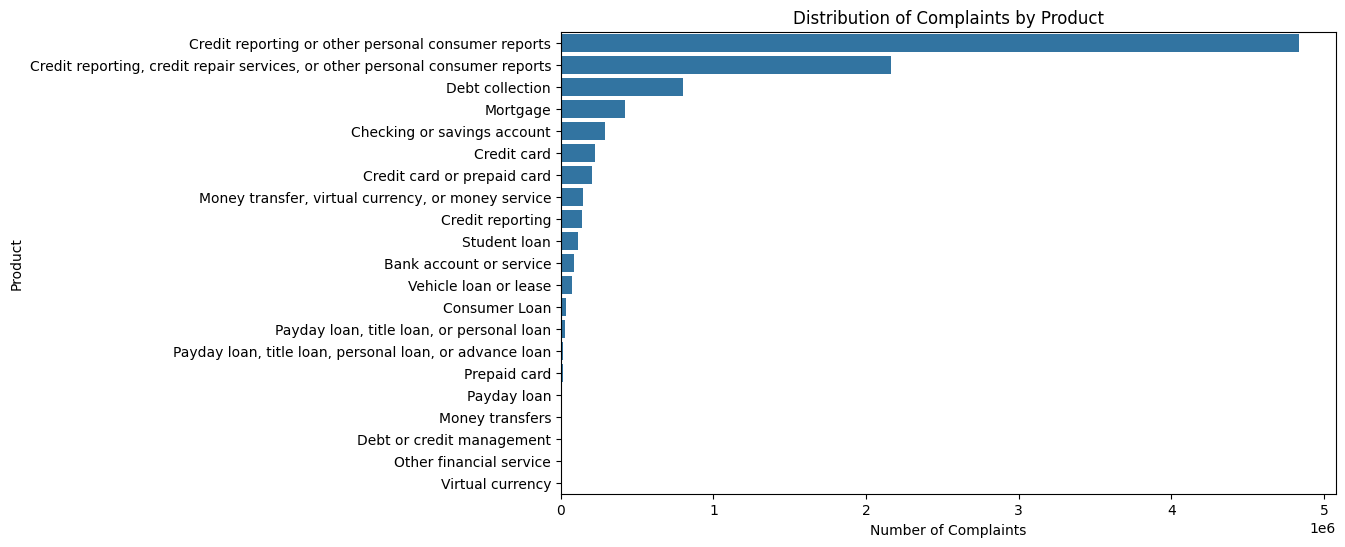


Narrative Length Statistics:
count    2.980756e+06
mean     1.909950e+02
std      2.454898e+02
min      1.000000e+00
25%      6.500000e+01
50%      1.230000e+02
75%      2.280000e+02
max      6.914000e+03
Name: narrative_length, dtype: float64


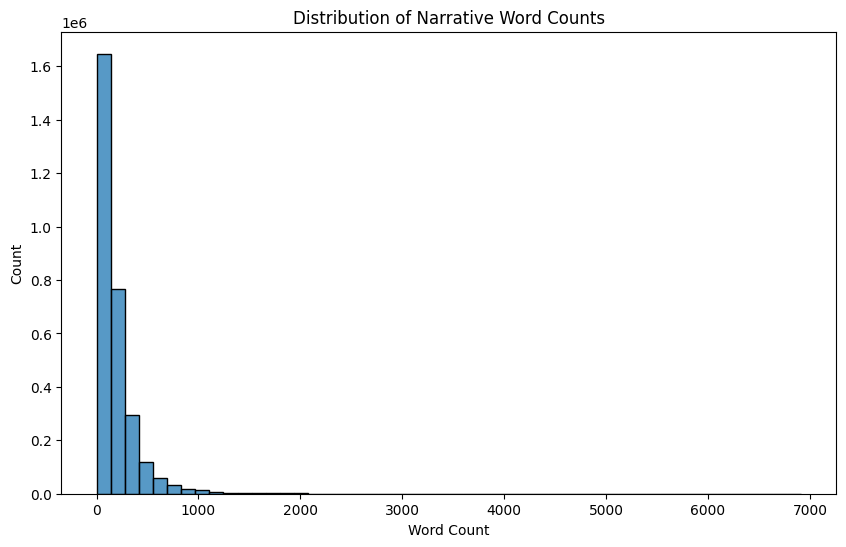


Complaints with/without narratives:
With narratives: 2980756
Without narratives: 6629041


In [12]:
# Dataset overview
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Distribution of complaints by product
product_counts = df['Product'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=product_counts.values, y=product_counts.index)
plt.title('Distribution of Complaints by Product')
plt.xlabel('Number of Complaints')
plt.savefig('Viz/product_distribution.png')
plt.show()

# Analyze narrative lengths
df['narrative_length'] = df['Consumer complaint narrative'].dropna().apply(lambda x: len(word_tokenize(str(x))))
print("\nNarrative Length Statistics:")
print(df['narrative_length'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['narrative_length'].dropna(), bins=50)
plt.title('Distribution of Narrative Word Counts')
plt.xlabel('Word Count')
plt.savefig('Viz/narrative_length_distribution.png')
plt.show()

# Complaints with and without narratives
narrative_counts = df['Consumer complaint narrative'].isna().value_counts()
print("\nComplaints with/without narratives:")
print(f"With narratives: {narrative_counts.get(False, 0)}")
print(f"Without narratives: {narrative_counts.get(True, 0)}")

## Data Preprocessing

Filter the dataset for the specified products and clean the narratives to improve embedding quality.

In [ ]:
# Text cleaning function
def clean_narrative(text):
    if pd.isna(text):
        return text
    # Lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove boilerplate phrases
    boilerplate_phrases = [
        r'i am writing to file a complaint',
        r'please assist',
        r'thank you for your attention'
    ]
    for phrase in boilerplate_phrases:
        text = re.sub(phrase, '', text, flags=re.IGNORECASE)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

# Preprocess data
def preprocess_data(df):
    # Filter for specified products
    target_products = [
        'Credit card',
        'Personal loan',
        'Buy Now, Pay Later (BNPL)',
        'Savings account',
        'Money transfers'
    ]
    df_filtered = df[df['Product'].isin(target_products)].copy()
    
    # Remove records with empty narratives
    df_filtered = df_filtered.dropna(subset=['Consumer complaint narrative'])
    
    # Clean narratives
    df_filtered['Consumer complaint narrative'] = df_filtered['Consumer complaint narrative'].apply(clean_narrative)
    
    # Remove any narratives that became empty after cleaning
    df_filtered = df_filtered[df_filtered['Consumer complaint narrative'].str.strip() != '']
    
    return df_filtered

## Save Processed Data

Save the filtered and cleaned dataset to `data/filtered_complaints.csv`.

In [11]:
# Create notebooks directory for plots
Path('viz').mkdir(exist_ok=True)

# Process and save data
print("Preprocessing data...")
df_processed = preprocess_data(df)
df_processed.to_csv(OUTPUT_PATH, index=False)
print(f"Filtered dataset saved to {OUTPUT_PATH}")
print("Processed dataset shape:", df_processed.shape)

Preprocessing data...


NameError: name 'preprocess_data' is not defined

## Summary of Findings

The Exploratory Data Analysis (EDA) on the CFPB complaint dataset revealed a diverse distribution of complaints across various products, with the specified products—Credit card, Personal loan, Buy Now, Pay Later (BNPL), Savings account, and Money transfers—representing a subset of the total complaints. The analysis of narrative lengths showed a wide range, with some narratives being very short (under 10 words) and others exceeding 500 words, indicating variability in complaint detail. A significant portion of complaints lacked narratives, which were subsequently filtered out to focus on records with meaningful text for the RAG pipeline. The distribution of complaints by product highlighted that Credit card complaints were the most frequent among the target products, while BNPL complaints were less common, possibly reflecting its newer market presence.

Preprocessing involved filtering the dataset to include only the five specified products and removing records with missing or empty Consumer complaint narratives. Text cleaning included lowercasing, removing special characters, numbers, and common boilerplate phrases (e.g., "I am writing to file a complaint"), resulting in cleaner narratives suitable for embedding. The cleaned dataset, reduced in size due to filtering, was saved as `data/filtered_complaints.csv` for use in subsequent project steps. Visualizations, including a product distribution bar plot and a narrative length histogram, were generated and saved in the `notebooks/` directory to aid in understanding the data's characteristics.